# Assignment 2 - Image Inpainting

Name: Ramon Näf <br>
Matriculation number: 20-116-950

In [1]:
from numpy import *
from PIL import Image
import matplotlib.pyplot as plt
from skimage.transform import resize
from tqdm import tqdm
from scipy import sparse
from scipy.signal import convolve2d
import numpy as np
from hessian_matrix import *
from scipy.sparse import triu, tril, diags
from scipy.sparse.linalg import spsolve

## Test Image

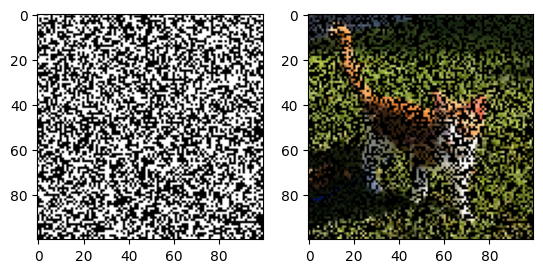

In [2]:
masked_img = np.array(Image.open('masked_cat.png')) / 255
omega = np.array(Image.open('mask.png'))/ 255
g = masked_img

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(omega, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(g)

## hessian_matrix() function

We provide the implementation of the hessian matrix.

input variables: 
- u: your image
- omega: binary mask
- reg: regularization parameter

Example usage:

In [3]:
u_ex = np.zeros(9).reshape(3,3)
reg_lambda = 2
k_type_ex = 3
A = hessian_matrix(u_ex, omega, reg_lambda)
A_n_t = A.toarray()
print(A_n_t)

[[ 8. -4.  0. -4.  0.  0.  0.  0.  0.]
 [-4. 14. -4.  0. -4.  0.  0.  0.  0.]
 [ 0. -4. 10.  0.  0. -4.  0.  0.  0.]
 [-4.  0.  0. 14. -4.  0. -4.  0.  0.]
 [ 0. -4.  0. -4. 18. -4.  0. -4.  0.]
 [ 0.  0. -4.  0. -4. 14.  0.  0. -4.]
 [ 0.  0.  0. -4.  0.  0. 10. -4.  0.]
 [ 0.  0.  0.  0. -4.  0. -4. 12. -4.]
 [ 0.  0.  0.  0.  0. -4.  0. -4. 10.]]


## Implementation


In [4]:
def GD(g, omega, lmbda):
    """
    Gradient Descent algorithm
    g: masked image of size (M, N, 3)
    omega: binary mask of size (M, N)
    lmbda: regularization parameter

    returns: u - inpainted image (M, N, 3)

    """
    u = g.copy() 


    # Stable parameters
    epsilon = 0.025 
    tol = 1e-5
    max_iter = 1000

    it = 0
    criterium = float("inf")

    while criterium > tol and it < max_iter:
        norms = []

        for c in range(3):
            grad_c = gradient(u[:, :, c], g[:, :, c], omega, lmbda)
            u[:, :, c] -= epsilon * grad_c

            u[:, :, c] = omega * g[:, :, c] + (1 - omega) * u[:, :, c]

            norms.append(np.linalg.norm(grad_c))

        criterium = max(norms)
        it += 1

    return u



def gradient(u, g, Omega, lam):
    """
    As described in the report.
    """
    N, M = u.shape
    grad = np.zeros_like(u)

    # Interior pixels 
    for i in range(1, N-1):
        for j in range(1, M-1):
            reg = 2 * lam * (4*u[i,j] - u[i-1,j] - u[i+1,j] - u[i,j-1] - u[i,j+1])
            data = 2 * Omega[i,j] * (u[i,j] - g[i,j])
            grad[i,j] = data + reg

    for j in range(1, M-1):
        # Left edge (i=0, 1 <= j <= M-2) 
        reg = 2 * lam * (3*u[0,j] - u[1,j] - u[0,j-1] - u[0,j+1])
        data = 2 * Omega[0,j] * (u[0,j] - g[0,j])
        grad[0,j] = data + reg

        # Right edge (i=N-1, 1 <= j <= M-2) 
        reg = 2 * lam * (3*u[N-1,j] - u[N-2,j] - u[N-1,j-1] - u[N-1,j+1])
        data = 2 * Omega[N-1,j] * (u[N-1,j] - g[N-1,j])
        grad[N-1,j] = data + reg

    for i in range(1, N-1):
        # Top edge (j=0, 1 <= i <= N-2) 
        reg = 2 * lam * (3*u[i,0] - u[i-1,0] - u[i+1,0] - u[i,1])
        data = 2 * Omega[i,0] * (u[i,0] - g[i,0])
        grad[i,0] = data + reg

        # Bottom edge (j=M-1, 1 <= i <= N-2) 
        reg = 2 * lam * (3*u[i,M-1] - u[i-1,M-1] - u[i+1,M-1] - u[i,M-2])
        data = 2 * Omega[i,M-1] * (u[i,M-1] - g[i,M-1])
        grad[i,M-1] = data + reg

    # Top-left corner (0,0) 
    reg = 2 * lam * (2*u[0,0] - u[1,0] - u[0,1])
    data = 2 * Omega[0,0] * (u[0,0] - g[0,0])
    grad[0,0] = data + reg

    # Top-right corner (N-1,0) 
    reg = 2 * lam * (2*u[N-1,0] - u[N-2,0] - u[N-1,1])
    data = 2 * Omega[N-1,0] * (u[N-1,0] - g[N-1,0])
    grad[N-1,0] = data + reg

    # Bottom-left corner (0,M-1) 
    reg = 2 * lam * (2*u[0,M-1] - u[1,M-1] - u[0,M-2])
    data = 2 * Omega[0,M-1] * (u[0,M-1] - g[0,M-1])
    grad[0,M-1] = data + reg

    # Bottom-right corner (N-1,M-1) 
    reg = 2 * lam * (2*u[N-1,M-1] - u[N-2,M-1] - u[N-1,M-2])
    data = 2 * Omega[N-1,M-1] * (u[N-1,M-1] - g[N-1,M-1])
    grad[N-1,M-1] = data + reg

    return grad




In [5]:
def LGS(g, omega, lmbda):
    """
    Gradient Descent algorithm
    g: masked image of size (M, N, 3)
    omega: binary mask of size (M, N)
    lmbda: regularization parameter

    returns: u - inpainted image (M, N, 3)

    """
    u = g.copy()
    M, N, _ = g.shape
    num_pix = M * N

    A = hessian_matrix(g, omega, lmbda).tocsr()

    D = diags(A.diagonal())
    L = tril(A, k=(-1)) 
    U = triu(A, k=(+1)) 

    DL = (D + L).tocsr()

    max_iter = 150 
    tol = 1e-5

    for c in range(3): 
        g_c = g[:, :, c]
        b = 2.0 * omega * g_c 
        b_vec = b.reshape(num_pix)

        x = g_c.reshape(num_pix)

        for _ in range(max_iter):
            x_old = x.copy()

            rhs = b_vec - U.dot(x)
            x = spsolve(DL, rhs)

            if np.linalg.norm(x - x_old) < tol * np.linalg.norm(x_old):
                break

        u[:, :, c] = x.reshape(M, N)

    return u

## GRADIENT DESCENT

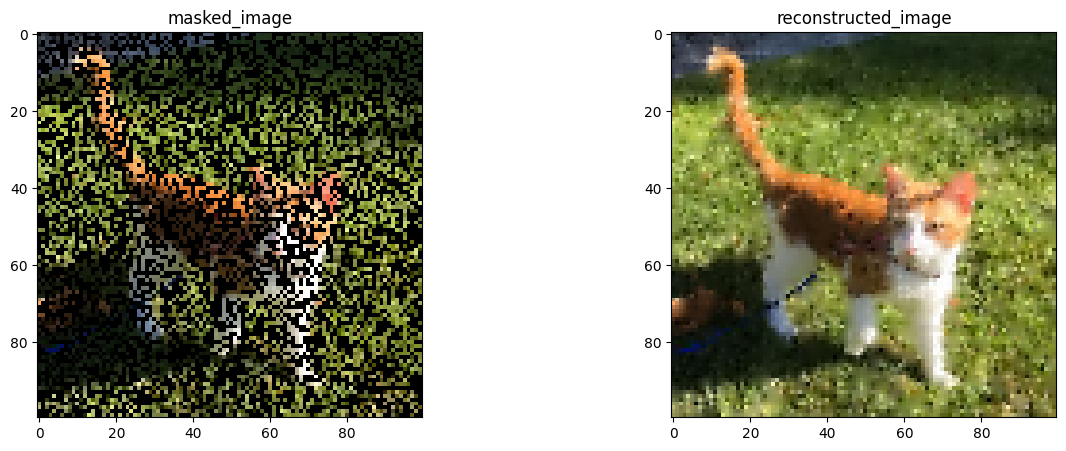

In [6]:
# run gradient descent algorithm
inpainted_img_gd = GD(g, omega, 2)

# for visualization purpose 
inpainted_img_gd = np.clip(inpainted_img_gd, 0, 1)


plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_gd)


ax1.set_title("masked_image")
ax2.set_title("reconstructed_image")
plt.show()

## GAUSS - SEIDEL

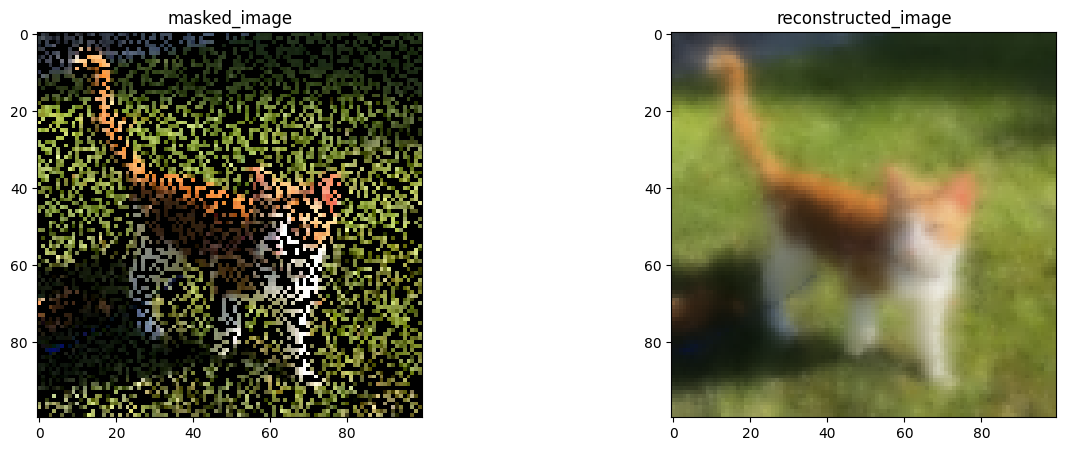

In [7]:
# run gradient descent algorithm
inpainted_img_lgs = LGS(g, omega, 2)

# for visualization purpose 
inpainted_img_lgs = np.clip(inpainted_img_lgs, 0, 1)


plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_lgs)


ax1.set_title("masked_image")
ax2.set_title("reconstructed_image")
plt.show()

### Effect of the regularization parameter lmbda 

As $\lambda$ increases, the reconstruction becomes smoother but loses sharpness.
- Small $\lambda$ preserves edges but produces noisy inpainting.
- moderate $\lambda$ yields the best balance between sharp details and smooth interpolation
- very large $\lambda$ overly smooths the image, causing blur and loss of structure.

In [8]:
lmbda_low = 0.0001
lmbda_moderate = 0.5
lmbda_high = 100

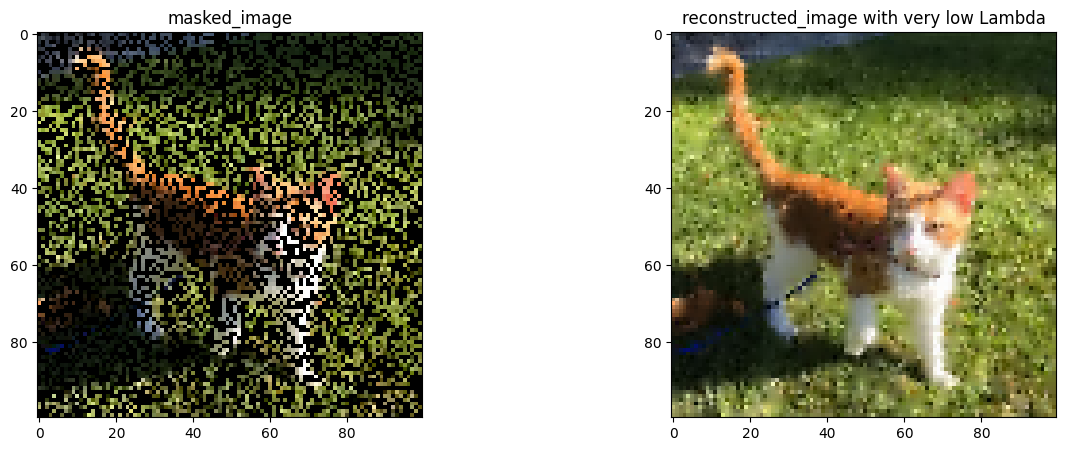

In [9]:
inpainted_img_lgs = LGS(g, omega, lmbda_low)
inpainted_img_lgs = np.clip(inpainted_img_lgs, 0, 1)

plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_lgs)
ax1.set_title("masked_image")
ax2.set_title("reconstructed_image with very low Lambda")
plt.show()


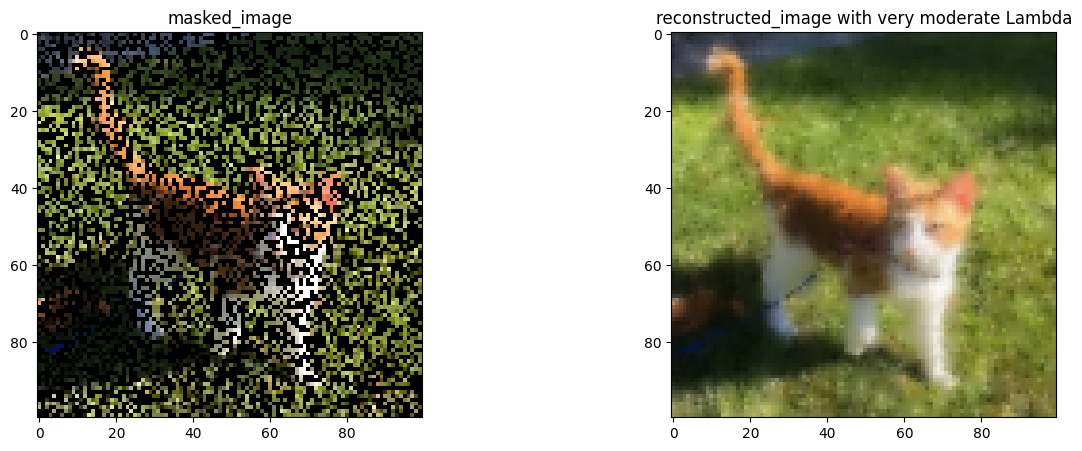

In [10]:
inpainted_img_lgs = LGS(g, omega, lmbda_moderate)
inpainted_img_lgs = np.clip(inpainted_img_lgs, 0, 1)

plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_lgs)
ax1.set_title("masked_image")
ax2.set_title("reconstructed_image with very moderate Lambda")
plt.show()

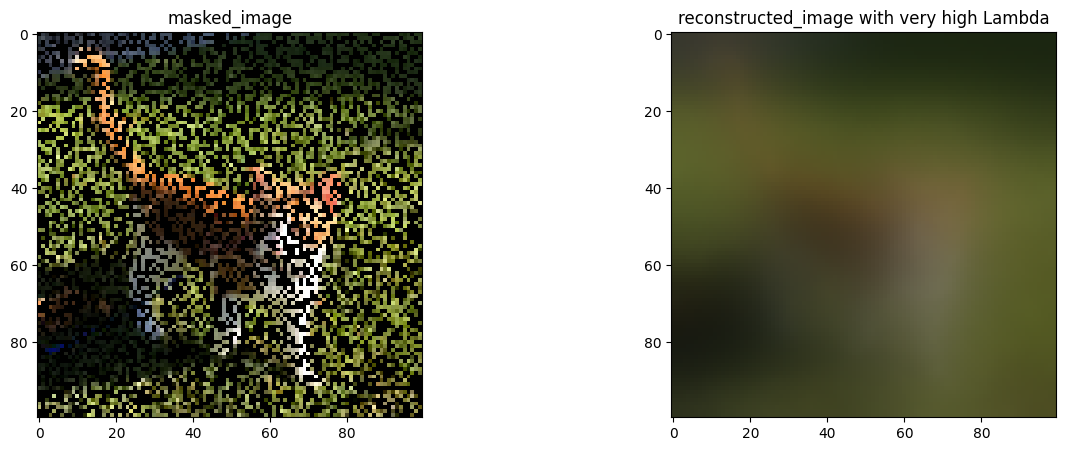

In [11]:
inpainted_img_lgs = LGS(g, omega, lmbda_high)
inpainted_img_lgs = np.clip(inpainted_img_lgs, 0, 1)

plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_lgs)
ax1.set_title("masked_image")
ax2.set_title("reconstructed_image with very high Lambda")
plt.show()